In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Import the model
from generator import load_generator, generate_regime_data, denormalize, returns_to_prices

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
%matplotlib inline

In [ ]:
# Configuration
CHECKPOINT_PATH = 'checkpoints/checkpoint_epoch_1000.pt' # This is the final model path
REGIME_LABEL = 0  # 0: Bearish, 1: Bullish, 2: Sideways, 3: Crash
REGIME_DICT = {
    0: 'Bearish',
    1: 'Bullish',
    2: 'Sideways',
    3: 'Crash'
}
N_SAMPLES = 500
INITIAL_PRICE = 100.0


gen, cfg = load_generator(CHECKPOINT_PATH)

normalized_returns = generate_regime_data(gen, regime_label=REGIME_LABEL, n_sequences=N_SAMPLES, **cfg)
actual_returns = denormalize(normalized_returns, cfg['global_mu'], cfg['global_sigma'])
price_paths = returns_to_prices(actual_returns, initial_price=INITIAL_PRICE)

print(f"Generated {N_SAMPLES} sequences for Regime {REGIME_LABEL}")
print(f"Shape: {price_paths.shape} (Scenarios x Days)")

[Inference] Loaded generator from epoch 1000
[Inference] Architecture: noise_dim=32, hidden=256, layers=2, regimes=4, embed=64
[Inference] Device: cpu
Generated 500 sequences for Regime 0
Shape: (500, 31) (Scenarios x Days)


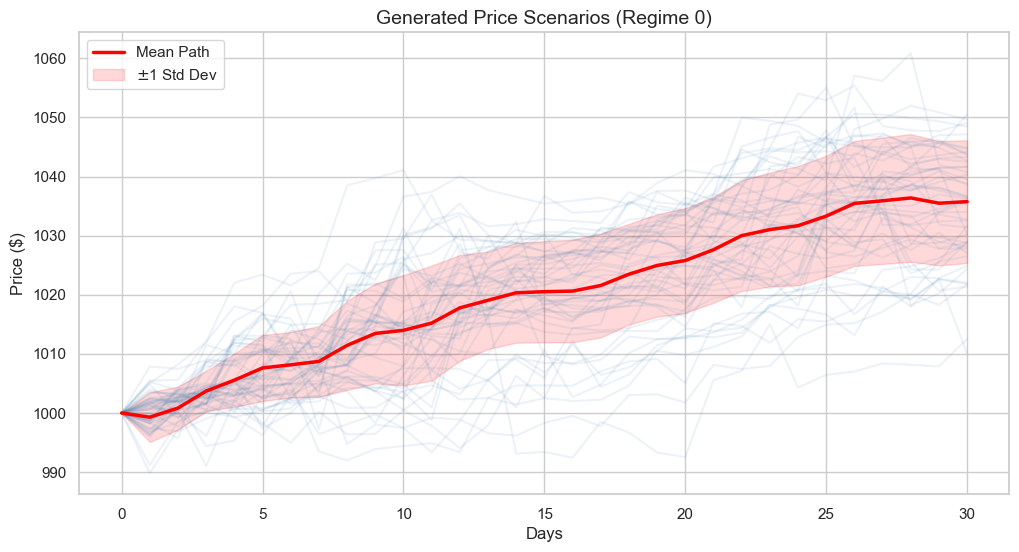

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(price_paths[:50].T, color='steelblue', alpha=0.1)

mean_path = np.mean(price_paths, axis=0)
plt.plot(mean_path, color='red', linewidth=2.5, label='Mean Path')

# Plot CI
std_path = np.std(price_paths, axis=0)
plt.fill_between(range(price_paths.shape[1]), 
                 mean_path - std_path, 
                 mean_path + std_path, 
                 color='red', alpha=0.15, label=r'$\pm$1 Std Dev')

plt.title(f"Generated Price Scenarios (Regime {REGIME_LABEL})", fontsize=14)
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

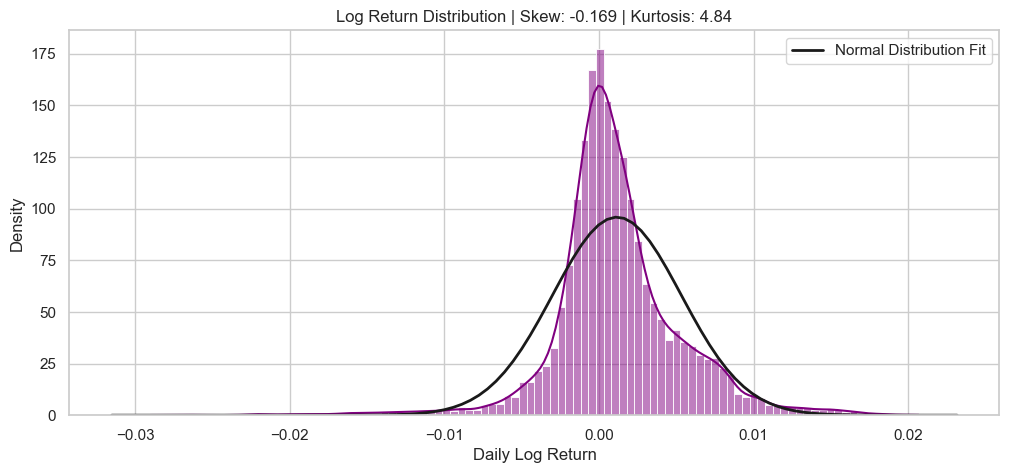

In [5]:
plt.figure(figsize=(12, 5))

# Flatten returns for distribution analysis
flat_returns = actual_returns.flatten()

# Histogram + KDE
sns.histplot(flat_returns, bins=100, kde=True, color='purple', stat="density")

# Add a normal distribution curve for comparison
mu, std = stats.norm.fit(flat_returns)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Normal Distribution Fit')

plt.title(f"Log Return Distribution | Skew: {stats.skew(flat_returns):.3f} | Kurtosis: {stats.kurtosis(flat_returns):.2f}")
plt.xlabel("Daily Log Return")
plt.legend()
plt.show()

In [6]:
# Format as your CSV output requires
df_export = pd.DataFrame(actual_returns, columns=[f'day_{i+1}' for i in range(actual_returns.shape[1])])
df_export.insert(0, 'scenario_id', range(len(df_export)))

output_name = f"generated_regime_{REGIME_LABEL}_returns.csv"
df_export.to_csv(output_name, index=False)
print(f"Saved generated data to {output_name}")

Saved generated data to generated_regime_0_returns.csv
